<a href="https://colab.research.google.com/github/DhanaSekhar-0-1/machine_learning/blob/main/LinerReg_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv('/content/house_prices_practice.csv')

df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB


,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,86.746758,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,75.750000,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,150.500000,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,225.250000,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,300.000000,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


In [ ]:

# ===============================
# 2. DATA CLEANING
# ===============================
df = df.drop('Id', axis=1)


In [ ]:
# ===============================
# 3. MULTIPLE LINEAR REGRESSION
# ===============================
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [ ]:
# ===============================
# 4. EVALUATION METRICS
# ===============================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== Multiple Linear Regression ===")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

=== Multiple Linear Regression ===
MAE : 10431.655979707499
MSE : 156386511.419058
RMSE: 12505.459264619512
R²  : 0.9724369952260797


In [ ]:
# ===============================
# 5. OVERFITTING CHECK
# ===============================
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print("\nOverfitting Check")
print("Train R²:", train_r2)
print("Test  R²:", test_r2)


Overfitting Check
Train R²: 0.97903560732947
Test  R²: 0.9724369952260797


In [ ]:
# ===============================
# 6. COEFFICIENT INTERPRETATION
# ===============================
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Coefficients:")
print(coeff_df)

print("\nIntercept (Bias):", model.intercept_)


Feature Coefficients:
        Feature   Coefficient
2    GarageCars  19109.641614
0   OverallQual  11914.688135
5      FullBath  11040.343046
6  BedroomAbvGr   4812.061994
4     YearBuilt    746.370978
1     GrLivArea     55.410257
3   TotalBsmtSF     25.199018
7       LotArea     -0.159522

Intercept (Bias): -1512820.5684315367


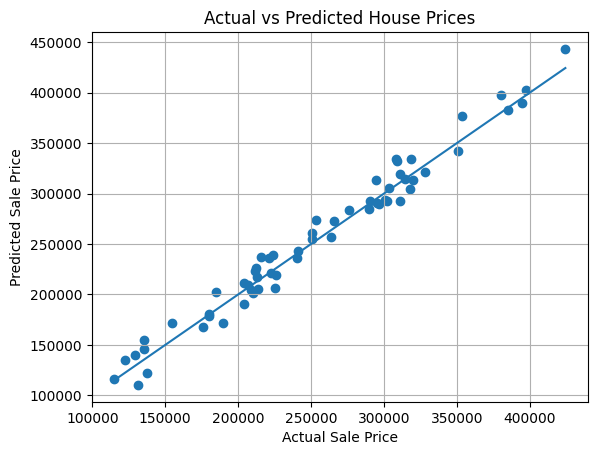

In [ ]:
# ===============================
# 7. VISUALIZATION
# ===============================
plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()

In [ ]:
# ===============================
# 8. SIMPLE LINEAR REGRESSION (COMPARISON)
# ===============================
X_simple = df[['GrLivArea']]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

y_pred_simple = simple_model.predict(X_test_s)

print("\n=== Simple Linear Regression ===")
print("Simple LR R²:", r2_score(y_test_s, y_pred_simple))
print("Multiple LR R²:", r2)


=== Simple Linear Regression ===
Simple LR R²: 0.46959557722940826
Multiple LR R²: 0.9724369952260797


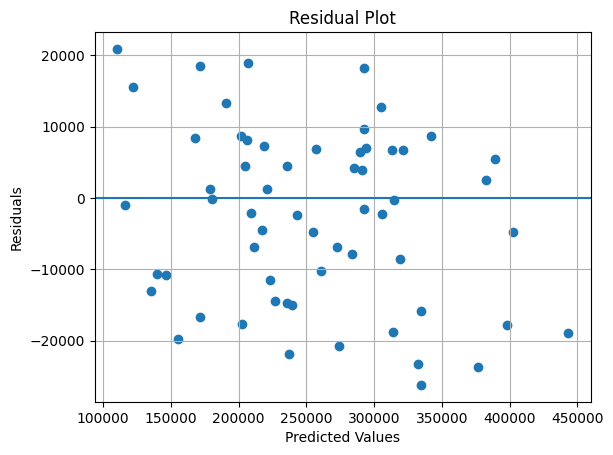

In [ ]:
# ===============================
# 9. RESIDUAL PLOT (ASSUMPTION CHECK)
# ===============================
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [ ]:
# ===============================
# 10. NEW HOUSE PREDICTION
# ===============================
new_house = pd.DataFrame({
    'OverallQual': [7],
    'GrLivArea': [2500],
    'GarageCars': [2],
    'TotalBsmtSF': [1500],
    'YearBuilt': [2015],
    'FullBath': [2],
    'BedroomAbvGr': [3],
    'LotArea': [9000]
})

predicted_price = model.predict(new_house)
print("\nPredicted House Price:", predicted_price[0])


Predicted House Price: 324144.3962463846
